 Praktikum 14 – Kubische Splines
Aufgabe 1 – Natürliche kubische Splineinterpolation

Gegeben ist die Funktion

$$
f(x)=\frac{1}{1+x^2}
$$

im Intervall ([-5,5]).

Für (n=6,;9,;15) werden äquidistant verteilte Punkte berechnet und mit natürlichen kubischen Splines interpoliert.

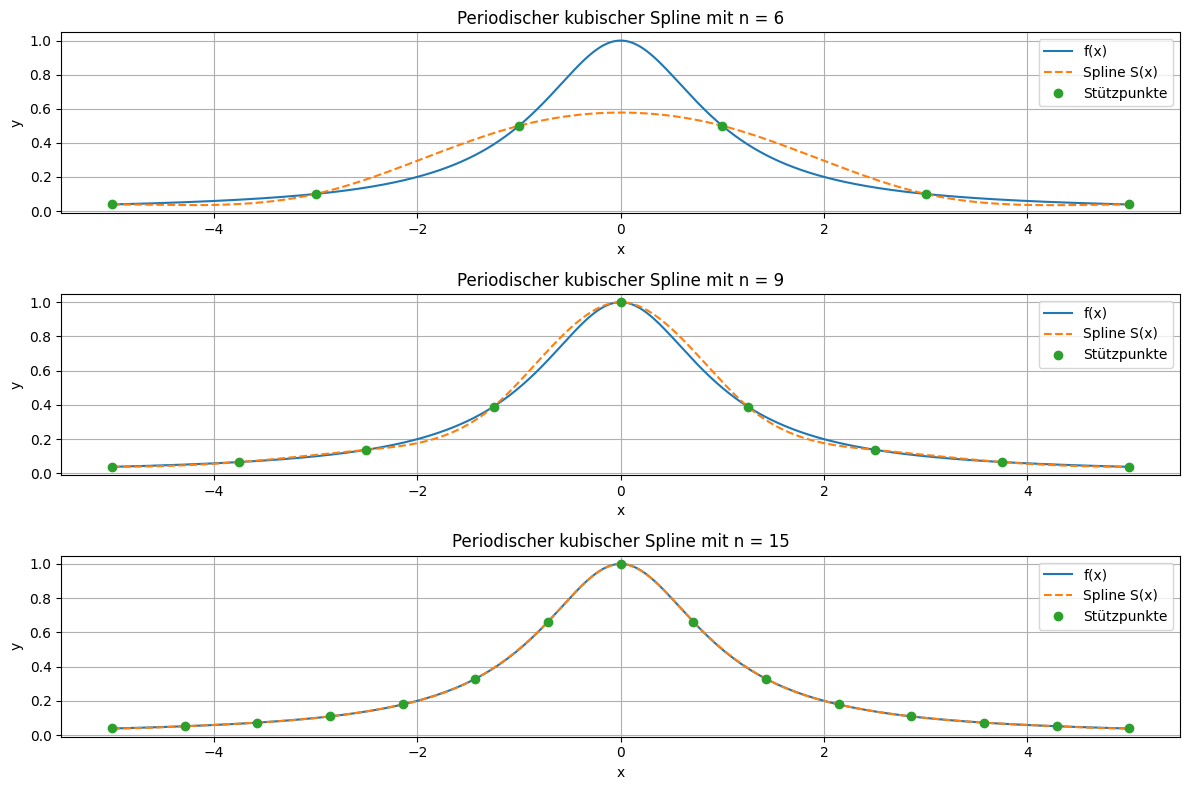

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def momentePer(y):
    N = len(y) - 1
    d = np.ones(N)
    A = np.diag(4 * d) + np.diag(d[1:], -1) + np.diag(d[:-1], 1) 
    A[0, -1] = 1
    A[-1, 0] = 1
    b = y[2:] - 2 * y[1:-1] + y[:-2]
    b = np.append(b, y[1] - y[-1] - y[0] + y[-2])
    b = b * (6 / h**2)
    m = np.zeros(N+1)
    m[1:] = np.linalg.solve(A, b)
    m[0] = m[-1]
    return m

def splineval(m, x, y, xx, der = 0):
    yy = np.zeros_like(xx)
    for j in range(len(x)-1):
        I = (xx >= x[j]) * (xx <= x[j+1])
        dp, dm = x[j+1] - xx[I], xx[I] - x[j]
        if der == 0: # Splinefunktion
            yy[I]  = ( dp**3 * m[j] + dm**3 * m[j+1] ) / (6 * h)
            yy[I] += ( dp    * y[j] + dm    * y[j+1] ) / h 
            yy[I] -= ( dp    * m[j] + dm    * m[j+1] ) * h / 6
        elif der == 1: # erste Ableitung
            yy[I]  = ( -3 * dp**2 * m[j] + 3 * dm**2 * m[j+1] ) / (6 * h)
            yy[I] += ( - y[j] + y[j+1] ) / h 
            yy[I] -= ( - m[j] + m[j+1] ) * h / 6            
        elif der == 2: # zweite Ableitung
            yy[I]  = ( dp * m[j] + dm * m[j+1] ) / h
        elif der == 3: # dritte Ableitung
            yy[I]  = ( - m[j] + m[j+1] ) / h            
    return yy

# Funktion definieren
def f(x_val):
    return 1 / (1 + x_val**2)

# Werte für n
n_values = [6, 9, 15]

# Fein aufgelöste x-Werte für Plot
x_fine = np.linspace(-5, 5, 1000)

plt.figure(figsize=(12, 8))

for i, n in enumerate(n_values, 1):
    # äquidistante Punkte
    x_pts = np.linspace(-5, 5, n)
    y_pts = f(x_pts)
    
    # Globale Schrittweite h für die Funktionen berechnen
    h = x_pts[1] - x_pts[0]

    # Momente berechnen
    m = momentePer(y_pts)

    # Splinewerte berechnen
    y_spline = splineval(m, x_pts, y_pts, x_fine, der=0)

    # Plot
    plt.subplot(3, 1, i)
    plt.plot(x_fine, f(x_fine), label='f(x)')
    plt.plot(x_fine, y_spline, '--', label='Spline S(x)')
    plt.plot(x_pts, y_pts, 'o', label='Stützpunkte')

    plt.title(f'Periodischer kubischer Spline mit n = {n}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

## Aufgabe 2 – Anwendung in der Robotersteuerung

Gegeben sind Zeit- und Positionswerte:

t = [0, 2, 4, 6, 8, 10, 12, 14, 16]

x = [-50, 200, 500, 750, 1000, 750, 500, 200, -50]

y = [200, 0, 250, 500, 250, 0, 250, 500, 200]
`

Zur Beschreibung der Bewegung werden zwei Splinefunktionen verwendet:

$$
S_x(t), \qquad S_y(t)
$$

Da Start- und Endpunkt identisch sind, eignet sich eine **periodische Randbedingung**, um eine glatte geschlossene Bewegungskurve zu erhalten.


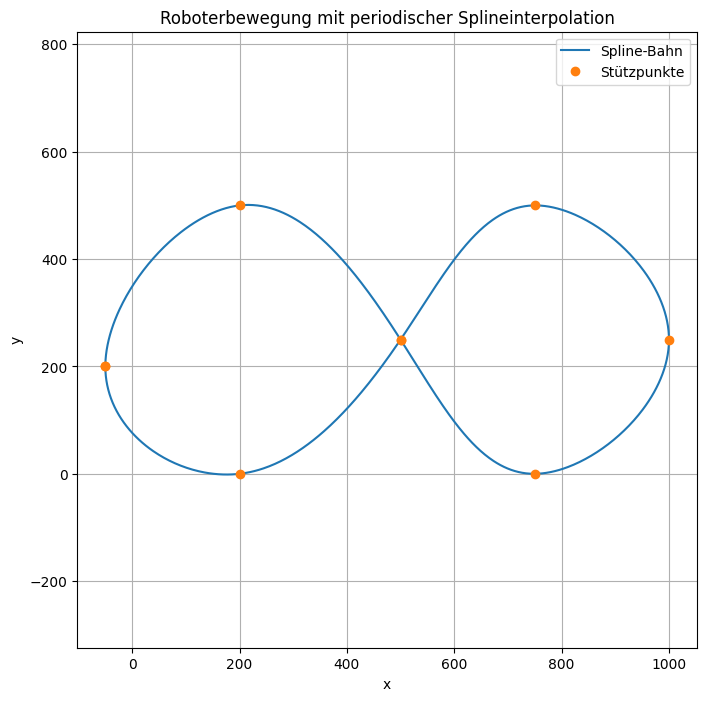

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def momentePer(y):
    N = len(y) - 1
    d = np.ones(N)
    A = np.diag(4 * d) + np.diag(d[1:], -1) + np.diag(d[:-1], 1) 
    A[0, -1] = 1
    A[-1, 0] = 1
    b = y[2:] - 2 * y[1:-1] + y[:-2]
    b = np.append(b, y[1] - y[-1] - y[0] + y[-2])
    b = b * (6 / h**2)
    m = np.zeros(N+1)
    m[1:] = np.linalg.solve(A, b)
    m[0] = m[-1]
    return m

def splineval(m, x, y, xx, der = 0):
    yy = np.zeros_like(xx)
    for j in range(len(x)-1):
        I = (xx >= x[j]) * (xx <= x[j+1])
        dp, dm = x[j+1] - xx[I], xx[I] - x[j]
        if der == 0: # Splinefunktion
            yy[I]  = ( dp**3 * m[j] + dm**3 * m[j+1] ) / (6 * h)
            yy[I] += ( dp    * y[j] + dm    * y[j+1] ) / h 
            yy[I] -= ( dp    * m[j] + dm    * m[j+1] ) * h / 6
        elif der == 1: # erste Ableitung
            yy[I]  = ( -3 * dp**2 * m[j] + 3 * dm**2 * m[j+1] ) / (6 * h)
            yy[I] += ( - y[j] + y[j+1] ) / h 
            yy[I] -= ( - m[j] + m[j+1] ) * h / 6            
        elif der == 2: # zweite Ableitung
            yy[I]  = ( dp * m[j] + dm * m[j+1] ) / h
        elif der == 3: # dritte Ableitung
            yy[I]  = ( - m[j] + m[j+1] ) / h            
    return yy

# Vorgabedaten (als Floats definiert)
t = np.array([0, 2, 4, 6, 8, 10, 12, 14, 16], dtype=float)
x_punkte = np.array([-50, 200, 500, 750, 1000, 750, 500, 200, -50], dtype=float)
y_punkte = np.array([200, 0, 250, 500, 250, 0, 250, 500, 200], dtype=float)

# Globale Schrittweite h berechnen
h = t[1] - t[0]

# Momente berechnen
m_x = momentePer(x_punkte)
m_y = momentePer(y_punkte)

# Fein aufgelöste Zeitwerte
t_fine = np.linspace(0, 16, 1000)

# Interpolierte Kurve auswerten
x_fine = splineval(m_x, t, x_punkte, t_fine, der=0)
y_fine = splineval(m_y, t, y_punkte, t_fine, der=0)

# Plot
plt.figure(figsize=(8, 8))
plt.plot(x_fine, y_fine, label='Spline-Bahn')
plt.plot(x_punkte, y_punkte, 'o', label='Stützpunkte')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Roboterbewegung mit periodischer Splineinterpolation')
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()